# 10 - Model Evaluation

In [1]:
from pathlib import Path
import json
import time

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy.sparse import load_npz
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.neighbors import NearestNeighbors

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 5)

PROJECT_DIR = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
PROCESSED_DIR = PROJECT_DIR / "data" / "processed"
MODEL_DIR = PROJECT_DIR / "models" / "content_based"
TABLES_DIR = PROJECT_DIR / "reports" / "tables"
FIGURES_DIR = PROJECT_DIR / "reports" / "figures" / "evaluation"
TABLES_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

tracks = pd.read_csv(PROCESSED_DIR / "content_tracks_engineered.csv")
track_id_to_index = dict(zip(tracks["track_id"], tracks["content_index"]))
print(tracks.shape)

(89740, 40)


## Load saved models

In [2]:
sound_matrix = np.load(MODEL_DIR / "cosine_feature_matrix.npy")
with open(MODEL_DIR / "knn_config.json", "r", encoding="utf-8") as file:
    knn_config = json.load(file)

mood_matrix = np.load(MODEL_DIR / "weighted_feature_matrix.npy")
with open(MODEL_DIR / "weighted_config.json", "r", encoding="utf-8") as file:
    weighted_config = json.load(file)

descriptor_matrix = load_npz(MODEL_DIR / "tfidf_matrix.npz")
tfidf_vectorizer = joblib.load(MODEL_DIR / "tfidf_vectorizer.joblib")
with open(MODEL_DIR / "tfidf_config.json", "r", encoding="utf-8") as file:
    tfidf_config = json.load(file)

hybrid_model = joblib.load(MODEL_DIR / "content_based_knn_tfidf_weighted_model.joblib")
hybrid_matrix = load_npz(MODEL_DIR / "tfidf_weighted_feature_matrix.npz")

## Recommend functions

In [3]:
def recommend_similar_tracks(track_id: str, top_n: int = 10) -> pd.DataFrame:
    query_index = track_id_to_index[track_id]
    query_genre = tracks.loc[query_index, "track_genre"]
    candidate_mask = (tracks["track_genre"] == query_genre) & (tracks["content_index"] != query_index)
    candidate_indices = tracks.index[candidate_mask].to_numpy()

    similarity = cosine_similarity(sound_matrix[[query_index]], sound_matrix[candidate_indices])[0]
    ranked_order = similarity.argsort()[::-1][:top_n]
    ranked_indices = candidate_indices[ranked_order]

    columns = ["track_id", "track_name", "artists", "track_genre", "popularity"]
    recs = tracks.loc[ranked_indices, columns].copy()
    recs["similarity_score"] = similarity[ranked_order]
    return recs.reset_index(drop=True)

In [4]:
def recommend_for_playlist(track_ids: list[str], top_n: int = 10) -> pd.DataFrame:
    indices = [track_id_to_index[tid] for tid in track_ids if tid in track_id_to_index]
    weights = tracks.loc[indices, "popularity"].to_numpy() + 1
    centroid = np.average(sound_matrix[indices], axis=0, weights=weights).reshape(1, -1)

    playlist_genres = set(tracks.loc[indices, "track_genre"])
    candidate_mask = tracks["track_genre"].isin(playlist_genres)
    candidate_mask.iloc[indices] = False
    candidate_indices = tracks.index[candidate_mask].to_numpy()

    knn = NearestNeighbors(n_neighbors=min(top_n, len(candidate_indices)), metric=knn_config["metric"], n_jobs=-1)
    knn.fit(sound_matrix[candidate_indices])
    distances, neighbor_positions = knn.kneighbors(centroid)

    ranked_indices = candidate_indices[neighbor_positions[0]]
    columns = ["track_id", "track_name", "artists", "track_genre", "popularity"]
    recs = tracks.loc[ranked_indices, columns].copy()
    recs["similarity_score"] = 1 - distances[0]
    return recs.reset_index(drop=True)

In [5]:
def recommend_by_mood(mood_label: str, top_n: int = 10) -> pd.DataFrame:
    candidate_indices = tracks.index[tracks["mood_label"] == mood_label].to_numpy()
    centroid = mood_matrix[candidate_indices].mean(axis=0, keepdims=True)
    similarity = cosine_similarity(centroid, mood_matrix[candidate_indices])[0]
    popularity_norm = tracks.loc[candidate_indices, "popularity"].to_numpy() / 100

    weight = weighted_config["similarity_weight"]
    combined_score = weight * similarity + (1 - weight) * popularity_norm
    ranked_order = combined_score.argsort()[::-1][:top_n]
    ranked_indices = candidate_indices[ranked_order]

    columns = ["track_id", "track_name", "artists", "track_genre", "popularity"]
    recs = tracks.loc[ranked_indices, columns].copy()
    recs["similarity_score"] = similarity[ranked_order]
    return recs.reset_index(drop=True)

In [6]:
def recommend_by_genre_query(query: str, top_n: int = 10) -> pd.DataFrame:
    primary_term = query.lower().split()[0]
    candidate_indices = tracks.index[tracks["track_genre"].str.contains(primary_term, case=False)].to_numpy()
    query_vector = tfidf_vectorizer.transform([query.lower()])
    similarity = cosine_similarity(query_vector, descriptor_matrix[candidate_indices])[0]
    popularity_norm = tracks.loc[candidate_indices, "popularity"].to_numpy() / 100

    weight = tfidf_config["relevance_weight"]
    combined_score = weight * similarity + (1 - weight) * popularity_norm
    ranked_order = combined_score.argsort()[::-1][:top_n]
    ranked_indices = candidate_indices[ranked_order]

    columns = ["track_id", "track_name", "artists", "track_genre", "popularity"]
    recs = tracks.loc[ranked_indices, columns].copy()
    recs["similarity_score"] = similarity[ranked_order]
    return recs.reset_index(drop=True)

In [7]:
def recommend_hybrid(track_id: str, top_n: int = 10) -> pd.DataFrame:
    query_index = track_id_to_index[track_id]
    distances, indices = hybrid_model.kneighbors(hybrid_matrix[query_index], n_neighbors=top_n + 1)
    rec_indices = indices.ravel()[1:]
    rec_distances = distances.ravel()[1:]

    columns = ["track_id", "track_name", "artists", "track_genre", "popularity"]
    recs = tracks.iloc[rec_indices][columns].copy()
    recs["similarity_score"] = 1 - rec_distances
    return recs.reset_index(drop=True)

## Metrics

In [8]:
def genre_precision_at_k(recommendations: pd.DataFrame, source_genre: str) -> float:
    if recommendations is None or len(recommendations) == 0:
        return 0.0
    return float((recommendations["track_genre"] == source_genre).mean())


def artist_precision_at_k(recommendations: pd.DataFrame, source_artist: str) -> float:
    if recommendations is None or len(recommendations) == 0:
        return 0.0
    return float((recommendations["artists"] == source_artist).mean())


def average_similarity_at_k(recommendations: pd.DataFrame) -> float:
    if recommendations is None or len(recommendations) == 0:
        return 0.0
    return float(recommendations["similarity_score"].mean())


def diversity_score(recommendations: pd.DataFrame) -> float:
    if recommendations is None or len(recommendations) == 0:
        return 0.0
    return float(recommendations["track_genre"].nunique() / len(recommendations))


def novelty_score(recommendations: pd.DataFrame) -> float:
    if recommendations is None or len(recommendations) == 0:
        return 0.0
    return float(1 - recommendations["popularity"].mean() / 100)


def duplicate_rate(recommendations: pd.DataFrame) -> float:
    if recommendations is None or len(recommendations) == 0:
        return 0.0
    return float((len(recommendations) - recommendations["track_id"].nunique()) / len(recommendations))

## Benchmark queries

In [9]:
SEED = 42

cosine_sample = tracks.sample(200, random_state=SEED)

playlist_genres = tracks["track_genre"].drop_duplicates().sample(15, random_state=SEED).tolist()
knn_playlists = [
    tracks[tracks["track_genre"] == genre].sample(3, random_state=SEED)["track_id"].tolist()
    for genre in playlist_genres
]

mood_labels = tracks["mood_label"].unique().tolist()
genre_queries = tracks["track_genre"].value_counts().head(15).index.tolist()

## Cosine - similar song

In [10]:
cosine_rows, cosine_recommended = [], set()
start = time.time()
for _, row in cosine_sample.iterrows():
    recs = recommend_similar_tracks(row["track_id"], top_n=10)
    cosine_rows.append({
        "genre_precision_at_k": genre_precision_at_k(recs, row["track_genre"]),
        "artist_precision_at_k": artist_precision_at_k(recs, row["artists"]),
        "average_similarity_at_k": average_similarity_at_k(recs),
        "diversity_score": diversity_score(recs),
        "novelty_score": novelty_score(recs),
        "avg_popularity": recs["popularity"].mean(),
        "duplicate_rate": duplicate_rate(recs),
    })
    cosine_recommended.update(recs["track_id"].tolist())
cosine_elapsed = (time.time() - start) / len(cosine_sample)

cosine_eval = pd.DataFrame(cosine_rows)
cosine_coverage = len(cosine_recommended) / len(tracks)
print(cosine_eval.mean(numeric_only=True).round(3))

genre_precision_at_k        1.000
artist_precision_at_k       0.134
average_similarity_at_k     0.876
diversity_score             0.100
novelty_score               0.686
avg_popularity             31.432
duplicate_rate              0.000
dtype: float64


## KNN - playlist

In [11]:
knn_rows, knn_recommended = [], set()
start = time.time()
for genre, playlist in zip(playlist_genres, knn_playlists):
    recs = recommend_for_playlist(playlist, top_n=10)
    knn_rows.append({
        "genre_precision_at_k": genre_precision_at_k(recs, genre),
        "average_similarity_at_k": average_similarity_at_k(recs),
        "diversity_score": diversity_score(recs),
        "novelty_score": novelty_score(recs),
        "avg_popularity": recs["popularity"].mean(),
        "duplicate_rate": duplicate_rate(recs),
    })
    knn_recommended.update(recs["track_id"].tolist())
knn_elapsed = (time.time() - start) / len(knn_playlists)

knn_eval = pd.DataFrame(knn_rows)
knn_coverage = len(knn_recommended) / len(tracks)
print(knn_eval.mean(numeric_only=True).round(3))

genre_precision_at_k        1.000
average_similarity_at_k     0.884
diversity_score             0.100
novelty_score               0.633
avg_popularity             36.653
duplicate_rate              0.000
dtype: float64


## Weighted - mood

In [12]:
weighted_rows, weighted_recommended = [], set()
start = time.time()
for mood in mood_labels:
    recs = recommend_by_mood(mood, top_n=10)
    weighted_rows.append({
        "average_similarity_at_k": average_similarity_at_k(recs),
        "diversity_score": diversity_score(recs),
        "novelty_score": novelty_score(recs),
        "avg_popularity": recs["popularity"].mean(),
        "duplicate_rate": duplicate_rate(recs),
    })
    weighted_recommended.update(recs["track_id"].tolist())
weighted_elapsed = (time.time() - start) / len(mood_labels)

weighted_eval = pd.DataFrame(weighted_rows)
weighted_coverage = len(weighted_recommended) / len(tracks)
print(weighted_eval.mean(numeric_only=True).round(3))

average_similarity_at_k     0.955
diversity_score             0.775
novelty_score               0.141
avg_popularity             85.900
duplicate_rate              0.000
dtype: float64


## TF-IDF - genre

In [13]:
tfidf_rows, tfidf_recommended = [], set()
start = time.time()
for genre in genre_queries:
    recs = recommend_by_genre_query(genre, top_n=10)
    tfidf_rows.append({
        "genre_precision_at_k": genre_precision_at_k(recs, genre),
        "average_similarity_at_k": average_similarity_at_k(recs),
        "diversity_score": diversity_score(recs),
        "novelty_score": novelty_score(recs),
        "avg_popularity": recs["popularity"].mean(),
        "duplicate_rate": duplicate_rate(recs),
    })
    tfidf_recommended.update(recs["track_id"].tolist())
tfidf_elapsed = (time.time() - start) / len(genre_queries)

tfidf_eval = pd.DataFrame(tfidf_rows)
tfidf_coverage = len(tfidf_recommended) / len(tracks)
print(tfidf_eval.mean(numeric_only=True).round(3))

genre_precision_at_k        1.000
average_similarity_at_k     0.823
diversity_score             0.100
novelty_score               0.392
avg_popularity             60.760
duplicate_rate              0.000
dtype: float64


## Hybrid (09) - same query set as cosine

In [14]:
hybrid_rows, hybrid_recommended = [], set()
start = time.time()
for _, row in cosine_sample.iterrows():
    recs = recommend_hybrid(row["track_id"], top_n=10)
    hybrid_rows.append({
        "genre_precision_at_k": genre_precision_at_k(recs, row["track_genre"]),
        "artist_precision_at_k": artist_precision_at_k(recs, row["artists"]),
        "average_similarity_at_k": average_similarity_at_k(recs),
        "diversity_score": diversity_score(recs),
        "novelty_score": novelty_score(recs),
        "avg_popularity": recs["popularity"].mean(),
        "duplicate_rate": duplicate_rate(recs),
    })
    hybrid_recommended.update(recs["track_id"].tolist())
hybrid_elapsed = (time.time() - start) / len(cosine_sample)

hybrid_eval = pd.DataFrame(hybrid_rows)
hybrid_coverage = len(hybrid_recommended) / len(tracks)
print(hybrid_eval.mean(numeric_only=True).round(3))

genre_precision_at_k        0.714
artist_precision_at_k       0.204
average_similarity_at_k     0.837
diversity_score             0.297
novelty_score               0.686
avg_popularity             31.403
duplicate_rate              0.000
dtype: float64


## Comparison table

In [15]:
comparison = pd.DataFrame([
    {
        "model": "Cosine Similarity", "use_case": "similar_song",
        "genre_precision_at_k": cosine_eval["genre_precision_at_k"].mean(),
        "artist_precision_at_k": cosine_eval["artist_precision_at_k"].mean(),
        "avg_popularity": cosine_eval["avg_popularity"].mean(),
        "diversity_score": cosine_eval["diversity_score"].mean(),
        "novelty_score": cosine_eval["novelty_score"].mean(),
        "catalog_coverage": cosine_coverage, "avg_response_time_s": cosine_elapsed,
    },
    {
        "model": "KNN", "use_case": "playlist",
        "genre_precision_at_k": knn_eval["genre_precision_at_k"].mean(),
        "artist_precision_at_k": np.nan,
        "avg_popularity": knn_eval["avg_popularity"].mean(),
        "diversity_score": knn_eval["diversity_score"].mean(),
        "novelty_score": knn_eval["novelty_score"].mean(),
        "catalog_coverage": knn_coverage, "avg_response_time_s": knn_elapsed,
    },
    {
        "model": "Weighted Mood Similarity", "use_case": "mood",
        "genre_precision_at_k": np.nan,
        "artist_precision_at_k": np.nan,
        "avg_popularity": weighted_eval["avg_popularity"].mean(),
        "diversity_score": weighted_eval["diversity_score"].mean(),
        "novelty_score": weighted_eval["novelty_score"].mean(),
        "catalog_coverage": weighted_coverage, "avg_response_time_s": weighted_elapsed,
    },
    {
        "model": "TF-IDF", "use_case": "genre",
        "genre_precision_at_k": tfidf_eval["genre_precision_at_k"].mean(),
        "artist_precision_at_k": np.nan,
        "avg_popularity": tfidf_eval["avg_popularity"].mean(),
        "diversity_score": tfidf_eval["diversity_score"].mean(),
        "novelty_score": tfidf_eval["novelty_score"].mean(),
        "catalog_coverage": tfidf_coverage, "avg_response_time_s": tfidf_elapsed,
    },
    {
        "model": "Hybrid (09)", "use_case": "similar_song",
        "genre_precision_at_k": hybrid_eval["genre_precision_at_k"].mean(),
        "artist_precision_at_k": hybrid_eval["artist_precision_at_k"].mean(),
        "avg_popularity": hybrid_eval["avg_popularity"].mean(),
        "diversity_score": hybrid_eval["diversity_score"].mean(),
        "novelty_score": hybrid_eval["novelty_score"].mean(),
        "catalog_coverage": hybrid_coverage, "avg_response_time_s": hybrid_elapsed,
    },
]).round(4)

comparison.to_csv(TABLES_DIR / "model_comparison.csv", index=False)
comparison

,model,use_case,genre_precision_at_k,artist_precision_at_k,avg_popularity,diversity_score,novelty_score,catalog_coverage,avg_response_time_s
0,Cosine Similarity,similar_song,1.000,0.134,31.4320,0.1000,0.6857,0.0219,0.0061
1,KNN,playlist,1.000,NaN,36.6533,0.1000,0.6335,0.0017,0.0151
2,Weighted Mood Similarity,mood,NaN,NaN,85.9000,0.7750,0.1410,0.0004,0.0083
3,TF-IDF,genre,1.000,NaN,60.7600,0.1000,0.3924,0.0017,0.0234
4,Hybrid (09),similar_song,0.714,0.204,31.4030,0.2965,0.6860,0.0220,0.0806


## Charts

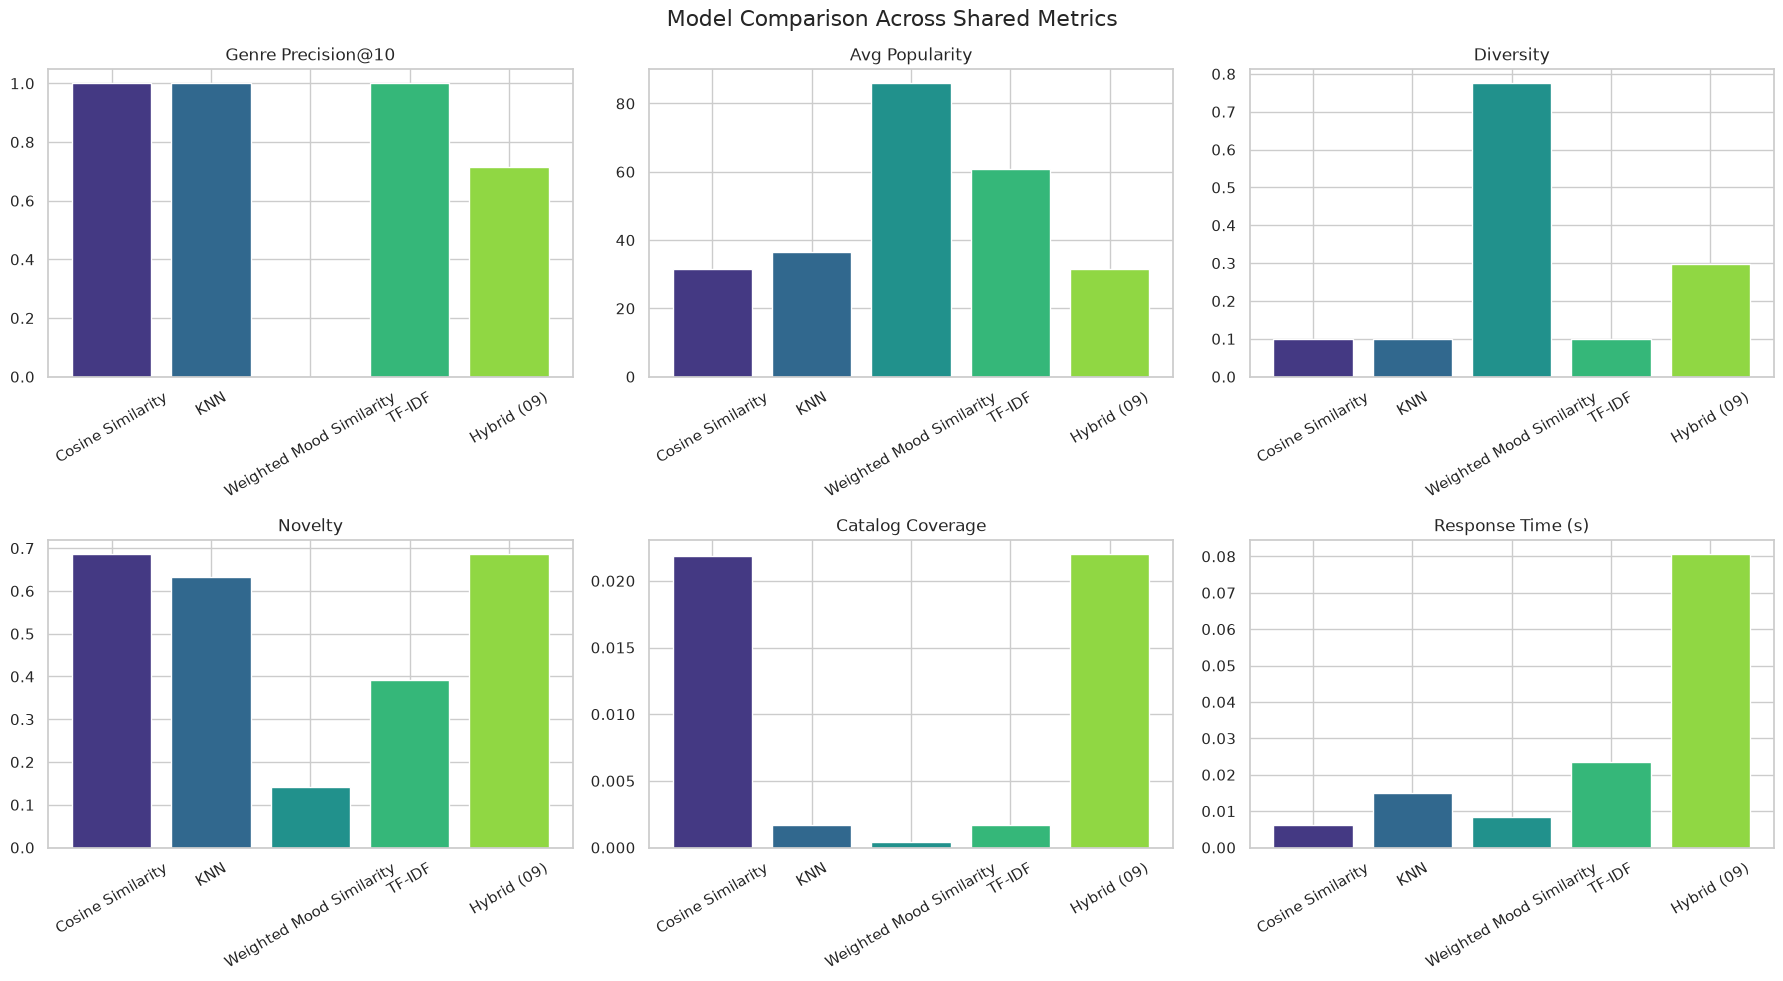

In [16]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
metrics_to_plot = [
    "genre_precision_at_k", "avg_popularity", "diversity_score",
    "novelty_score", "catalog_coverage", "avg_response_time_s",
]
titles = ["Genre Precision@10", "Avg Popularity", "Diversity", "Novelty", "Catalog Coverage", "Response Time (s)"]
palette = sns.color_palette("viridis", len(comparison))

for ax, metric, title in zip(axes.ravel(), metrics_to_plot, titles):
    ax.bar(comparison["model"], comparison[metric].fillna(0), color=palette)
    ax.set_title(title)
    ax.tick_params(axis="x", rotation=30)

plt.suptitle("Model Comparison Across Shared Metrics", fontsize=16)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "model_comparison.png", bbox_inches="tight")
plt.show()